In [25]:
ls

all_data_decomposed_100ms_1core.csv
all_data_decomposed_100ms_apiserver_pinned.csv
all_data_decomposed_100ms.csv
all_data_decomposed_10ms_1core.csv
all_data_decomposed_10ms_apiserver_pinned.csv
all_data_decomposed_10ms.csv
all_data_decomposed_1s_1core.csv
all_data_decomposed_1s_apiserver_pinned.csv
all_data_decomposed_1s.csv
all_data_decomposed_200ms_1core.csv
all_data_decomposed_200ms_apiserver_pinned.csv
all_data_decomposed_200ms.csv
all_data_decomposed_50ms_1core.csv
all_data_decomposed_50ms_apiserver_pinned.csv
all_data_decomposed_50ms.csv
coldrate_analysis.pdf
coldrate_analysis.png
cold_rate.csv
Untitled4.ipynb
Untitled.ipynb


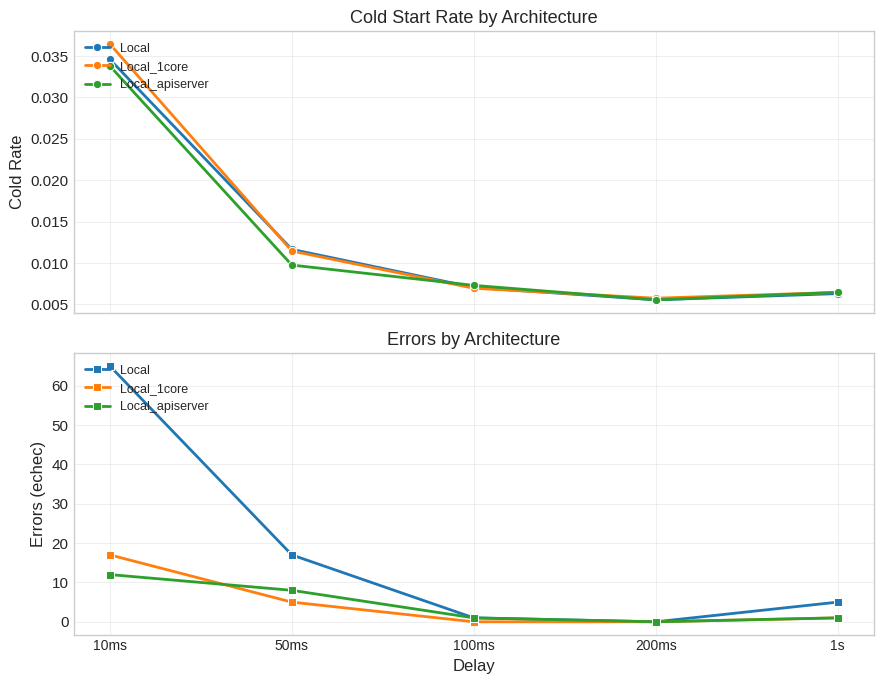

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ─── STYLE ─────────────────────────────────────────────
plt.style.use("seaborn-v0_8-whitegrid")

# ─── LOAD DATA ────────────────────────────────────────
df = pd.read_csv("cold_rate.csv")

# ─── AGGREGATION ──────────────────────────────────────
agg = df.groupby(["Architecture", "Delai"], as_index=False).agg({
    "cold starts": "sum",
    "total requests": "sum",
    "echec": "sum"
})

# cold rate
agg["cold_rate"] = agg["cold starts"] / agg["total requests"]

# order delays
order = ["10ms", "50ms", "100ms", "200ms", "1s"]
agg["Delai"] = pd.Categorical(agg["Delai"], categories=order, ordered=True)
agg = agg.sort_values("Delai")

# ─── FIGURE (2 SUBPLOTS) ──────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

# ─── 1) COLD RATE ─────────────────────────────────────
sns.lineplot(
    data=agg,
    x="Delai",
    y="cold_rate",
    hue="Architecture",
    marker="o",
    linewidth=2,
    ax=ax1
)

ax1.set_title("Cold Start Rate by Architecture")
ax1.set_ylabel("Cold Rate")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)

# ─── 2) ERRORS ────────────────────────────────────────
sns.lineplot(
    data=agg,
    x="Delai",
    y="echec",
    hue="Architecture",
    marker="s",
    linewidth=2,
    ax=ax2
)

ax2.set_title("Errors by Architecture")
ax2.set_ylabel("Errors (echec)")
ax2.set_xlabel("Delay")
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(True, alpha=0.3)

# ─── FINAL LAYOUT ─────────────────────────────────────
plt.tight_layout()

# ─── EXPORT ───────────────────────────────────────────
plt.savefig("coldrate_analysis.pdf", dpi=300, bbox_inches="tight")
plt.savefig("coldrate_analysis.png", dpi=300, bbox_inches="tight")

plt.show()

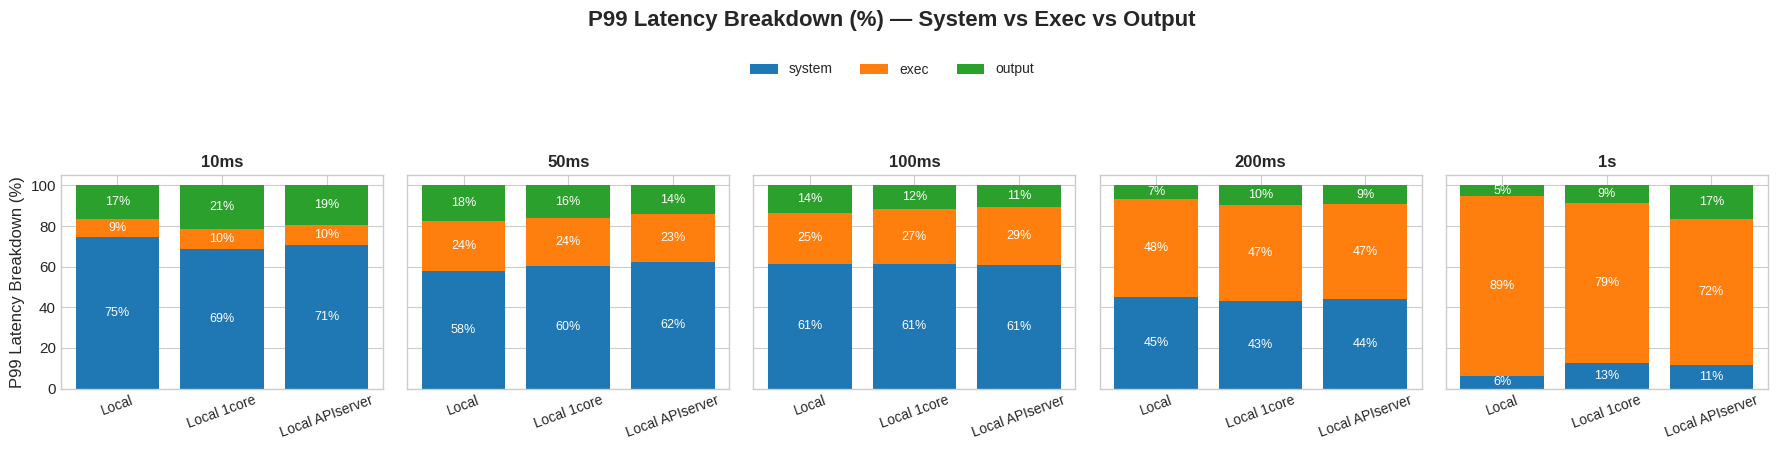

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# ─── STYLE ─────────────────────────────────────────────
plt.style.use("seaborn-v0_8-whitegrid")

COLORS = {
    "system": "#1f77b4",
    "exec": "#ff7f0e",
    "output": "#2ca02c"
}

# ─── CONFIG ───────────────────────────────────────────
DELAYS = ["10ms", "50ms", "100ms", "200ms", "1s"]

FILES = {
    "Local": {
        d: os.path.join(".", f"all_data_decomposed_{d}.csv") for d in DELAYS
    },
    "Local 1core": {
        d: os.path.join(".", f"all_data_decomposed_{d}_1core.csv") for d in DELAYS
    },
    "Local APIserver": {
        d: os.path.join(".", f"all_data_decomposed_{d}_apiserver_pinned.csv") for d in DELAYS
    },
}

MODES = list(FILES.keys())

# ─── LOAD ─────────────────────────────────────────────
def load_df(path):
    if not os.path.exists(path):
        return None
    return pd.read_csv(path)

# ─── P99 BREAKDOWN (EN %) ─────────────────────────────
def get_p99_breakdown_percent(df):
    if df is None or df.empty:
        return None

    threshold = df["latency_ms"].quantile(0.99)
    top = df[df["latency_ms"] >= threshold]

    if top.empty:
        return None

    system = top["system_overhead_ms"]
    exec_t = top["execution_time_ms"]
    output = top["output_transfer_ms"]

    total = system + exec_t + output

    return {
        "system": (system / total).mean() * 100,
        "exec": (exec_t / total).mean() * 100,
        "output": (output / total).mean() * 100,
    }

# ─── COLLECT DATA ─────────────────────────────────────
results = []

for mode in MODES:
    for delay in DELAYS:
        df = load_df(FILES[mode][delay])
        breakdown = get_p99_breakdown_percent(df)

        if breakdown is None:
            continue

        results.append({
            "mode": mode,
            "delay": delay,
            **breakdown
        })

agg = pd.DataFrame(results)

agg["delay"] = pd.Categorical(
    agg["delay"],
    categories=DELAYS,
    ordered=True
)

agg = agg.sort_values(["mode", "delay"])

# ─── PLOT ─────────────────────────────────────────────
fig, axes = plt.subplots(
    1,
    len(DELAYS),
    figsize=(18, 4),
    sharey=True
)

if len(DELAYS) == 1:
    axes = [axes]

for i, delay in enumerate(DELAYS):

    ax = axes[i]
    sub = agg[agg["delay"] == delay]

    bottom = np.zeros(len(sub))

    for key in ["system", "exec", "output"]:

        bars = ax.bar(
            sub["mode"],
            sub[key],
            bottom=bottom,
            color=COLORS[key],
            label=key if i == 0 else None
        )

        # ─── LABELS ────────────────────────────────
        for j, (bar, val) in enumerate(zip(bars, sub[key])):

            if val > 0:

                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bottom[j] + val / 2,
                    f"{val:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=9,
                    color="white"
                )

        bottom += sub[key].values

    # ─── AXES ────────────────────────────────────
    ax.set_title(
        delay,
        fontweight="bold",
        fontsize=12
    )

    ax.set_xticks(range(len(sub["mode"])))
    ax.set_xticklabels(sub["mode"], rotation=20)

    if i == 0:
        ax.set_ylabel("P99 Latency Breakdown (%)")

# ─── LEGEND ──────────────────────────────────────────
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 1.02)
)

# ─── TITLE ───────────────────────────────────────────
plt.suptitle(
    "P99 Latency Breakdown (%) — System vs Exec vs Output",
    fontsize=16,
    fontweight="bold",
    y=1.12
)

plt.tight_layout(rect=[0, 0, 1, 0.90])

# ─── EXPORT ──────────────────────────────────────────
plt.savefig(
    "p99_breakdown_percent.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "p99_breakdown_percent.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
df = pd.read_csv("all_data_decomposed_10ms.csv")  # adapte le nom

print(df.head())
print(df.columns)
print(df.shape)

   index   function   size  type status  latency_ms  time_to_first_byte_ms  \
0      0  fetchdata  small  warm    200     6283.49                6283.48   
1      1    linpack  small  cold    200     5421.22                5421.21   
2      2  grayscale  small  cold    200     4680.10                4677.04   
3      3  fetchdata  large  warm    200     7959.87                7959.80   
4      4     resnet  small  cold    200     5380.34                5380.33   

   output_transfer_ms  execution_time_ms  system_overhead_ms  \
0                0.01              91.62             6191.85   
1                0.01               5.86             5415.35   
2                3.06              32.29             4644.76   
3                0.07              81.98             7877.82   
4                0.01             452.52             4927.80   

   in_flight_at_send  
0                  1  
1                  2  
2                  3  
3                  4  
4                  5  
Index(['

In [11]:
df["latency_ms"].describe()

count    19949.000000
mean      1441.032849
std       3195.333038
min          3.580000
25%         98.770000
50%        439.190000
75%       1416.770000
max      38971.850000
Name: latency_ms, dtype: float64

In [12]:
p99 = df["latency_ms"].quantile(0.99)
print("p99 =", p99)

p99 = 18714.50080000003


In [13]:
top[[
    "latency_ms",
    "system_overhead_ms",
    "execution_time_ms",
    "output_transfer_ms"
]].describe()

,latency_ms,system_overhead_ms,execution_time_ms,output_transfer_ms
count,820.000000,820.000000,820.000000,820.000000
mean,3008.716476,537.547951,2215.369671,255.799244
std,709.082106,817.507967,1073.867135,393.619083
min,1513.160000,4.630000,0.170000,0.010000
25%,2855.110000,47.747500,2737.292500,62.070000
50%,2902.435000,138.655000,2767.425000,64.070000
75%,3516.257500,838.167500,2785.282500,605.760000
max,6124.230000,4027.510000,2894.000000,3235.630000


In [14]:
top["latency_ms"].describe()

count     820.000000
mean     3008.716476
std       709.082106
min      1513.160000
25%      2855.110000
50%      2902.435000
75%      3516.257500
max      6124.230000
Name: latency_ms, dtype: float64

In [15]:
top.sample(5)

,index,function,size,type,status,latency_ms,time_to_first_byte_ms,output_transfer_ms,execution_time_ms,system_overhead_ms,in_flight_at_send
11583,1583,grayscale,large,warm,200,2905.97,2839.77,66.20,2789.10,50.67,1
1882,1882,grayscale,large,warm,200,3498.92,2893.02,605.91,2754.19,138.82,1
15506,1506,grayscale,large,warm,200,3545.20,2938.73,606.46,2796.62,142.11,1
12624,624,grayscale,large,warm,200,3659.52,3583.90,75.62,2731.33,852.57,2
5319,1319,grayscale,large,warm,200,3505.84,2899.99,605.85,2760.60,139.39,1


In [16]:
p99 = df["latency_ms"].quantile(0.99)

closest = df.iloc[(df["latency_ms"] - p99).abs().argsort().head(10)]

print(closest[["latency_ms"]])

       latency_ms
8161     18748.72
12150    18677.43
688      18675.81
230      18792.87
10223    18808.60
227      18809.53
10231    18598.40
8150     18596.08
8149     18833.92
19030      104.75


/tmp/ipykernel_2622779/114524323.py:3: FutureWarning: The behavior of Series.argsort in the presence of NA values is deprecated. In a future version, NA values will be ordered last instead of set to -1.
  closest = df.iloc[(df["latency_ms"] - p99).abs().argsort().head(10)]


In [17]:
df["latency_ms"].describe(percentiles=[0.5, 0.9, 0.95, 0.99, 0.999])

count    19949.000000
mean      1441.032849
std       3195.333038
min          3.580000
50%        439.190000
90%       3408.128000
95%       5470.124000
99%      18714.500800
99.9%    34762.761680
max      38971.850000
Name: latency_ms, dtype: float64

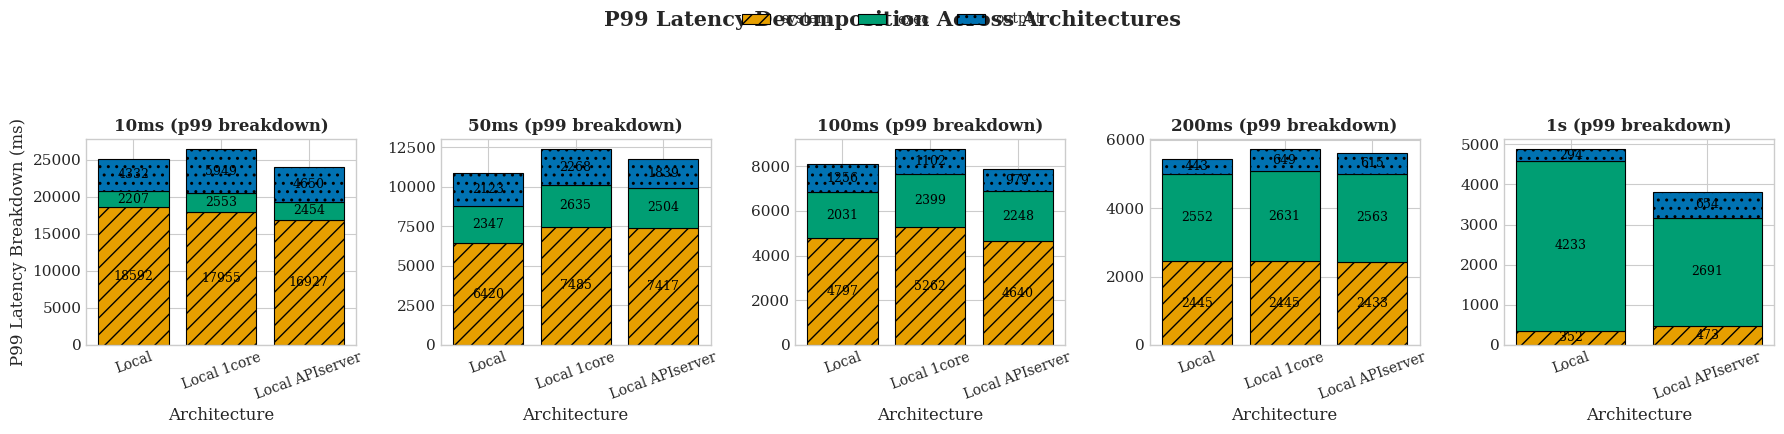

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# ─── STYLE (YOUR SPEC) ────────────────────────────────────────────────
COLORS  = {"system": "#E69F00", "exec": "#009E73", "output": "#0072B2"}
HATCHES = {"system": "//", "exec": "", "output": ".."}
DELAYS  = ["10ms", "50ms", "100ms", "200ms", "1s"]

FILES = {
    "Local": {
        d: os.path.join(".", f"all_data_decomposed_{d}.csv") for d in DELAYS
    },
    "Local 1core": {
        d: os.path.join(".", f"all_data_decomposed_{d}_1core.csv") for d in DELAYS
    },
    "Local APIserver": {
        d: os.path.join(".", f"all_data_decomposed_{d}_apiserver_pinned.csv") for d in DELAYS
    },
}

MODES = list(FILES.keys())

# ─── LOAD ─────────────────────────────────────────────────────────────
def load_df(path):
    if not os.path.exists(path):
        return None
    return pd.read_csv(path)

# ─── P99 BREAKDOWN (DIAGNOSTIC) ───────────────────────────────────────
def get_p99_breakdown(df):
    if df is None or df.empty:
        return None

    threshold = df["latency_ms"].quantile(0.99)
    top = df[df["latency_ms"] >= threshold]

    if top.empty:
        return None

    return {
        "system": top["system_overhead_ms"].mean(),
        "exec": top["execution_time_ms"].mean(),
        "output": top["output_transfer_ms"].mean(),
    }

# ─── COLLECT DATA ─────────────────────────────────────────────────────
results = []

for mode in MODES:
    for delay in DELAYS:
        df = load_df(FILES[mode][delay])
        breakdown = get_p99_breakdown(df)

        if breakdown is None:
            continue

        results.append({
            "mode": mode,
            "delay": delay,
            **breakdown
        })

agg = pd.DataFrame(results)

agg["delay"] = pd.Categorical(agg["delay"], categories=DELAYS, ordered=True)
agg = agg.sort_values(["mode", "delay"])

# ─── PLOT ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(DELAYS), figsize=(18, 4), sharey=False)

if len(DELAYS) == 1:
    axes = [axes]

for i, delay in enumerate(DELAYS):
    ax = axes[i]
    sub = agg[agg["delay"] == delay]

    bottom = np.zeros(len(sub))

    for key in ["system", "exec", "output"]:
        bars = ax.bar(
            sub["mode"],
            sub[key],
            bottom=bottom,
            color=COLORS[key],
            hatch=HATCHES[key],
            edgecolor="black",
            linewidth=0.8,
            label=key if i == 0 else None
        )

        # ─── VALUE LABELS ─────────────────────────────
        for j, (bar, val) in enumerate(zip(bars, sub[key])):
            if val > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bottom[j] + val / 2,
                    f"{val:.0f}",
                    ha="center",
                    va="center",
                    fontsize=9,
                    color="black"
                )

        bottom += sub[key].values

    # ─── AXES ───────────────────────────────────────
    ax.set_title(f"{delay} (p99 breakdown)", fontweight="bold", fontsize=12)

    ax.set_xticks(range(len(sub["mode"])))
    ax.set_xticklabels(sub["mode"], rotation=20)

    ax.set_xlabel("Architecture")

    if i == 0:
        ax.set_ylabel("P99 Latency Breakdown (ms)")

# ─── LEGEND ──────────────────────────────────────────
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)

# ─── TITLE ───────────────────────────────────────────
plt.suptitle(
    "P99 Latency Decomposition Across Architectures",
    fontsize=15,
    fontweight="bold",
    y=1.08
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

# ─── EXPORT ──────────────────────────────────────────
plt.savefig("p99_decomposition_style.pdf", dpi=300, bbox_inches="tight")
plt.savefig("p99_decomposition_style.png", dpi=300, bbox_inches="tight")

plt.show()